In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


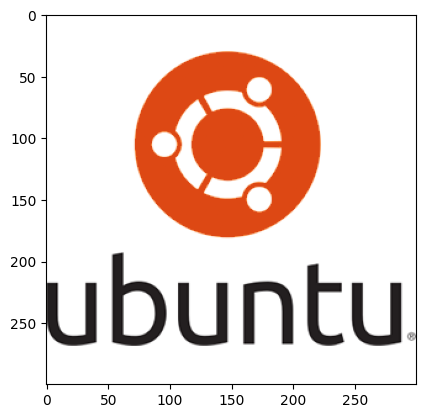

In [5]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

img = mpimg.imread('./drive/MyDrive/myData.png')
plt.imshow(img)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# -------------------------------
# 1. vehicle_prod.csv
# -------------------------------
vehicle_path = '/content/drive/MyDrive/Machine Learning/vehicle_prod.csv'
df = pd.read_csv(vehicle_path, index_col=0)

print("\n처음 5행")
print(df.head())
print("데이터 프레임 크기:", df.shape)
print("\n열 이름")
print(df.columns)

print("\n2009, 2010, 2011 열 선택")
print(df[['2009', '2010', '2011']])

print("\nKorea의 2011년 생산량")
print(df.loc['Korea', '2011'])

print("\nChina, Korea의 2011년 생산량")
print(df.loc[['China', 'Korea'], '2011'])

df['total'] = df.loc[:, '2007':'2011'].sum(axis=1)

print("\ntotal 열 추가 후")
print(df)

print("\ntotal이 가장 큰 국가")
print(df['total'].idxmax())


처음 5행
        2007   2008   2009   2010   2011
China   7.71   7.95  11.96  15.84  16.33
EU     19.02  17.71  15.00  16.70  17.48
US     10.47   8.45   5.58   7.60   8.40
Japan  10.87  10.83   7.55   9.09   7.88
Korea   4.04   3.78   3.45   4.20   4.62
데이터 프레임 크기: (6, 5)

열 이름
Index(['2007', '2008', '2009', '2010', '2011'], dtype='object')

2009, 2010, 2011 열 선택
         2009   2010   2011
China   11.96  15.84  16.33
EU      15.00  16.70  17.48
US       5.58   7.60   8.40
Japan    7.55   9.09   7.88
Korea    3.45   4.20   4.62
Mexico   1.50   2.25   2.54

Korea의 2011년 생산량
4.62

China, Korea의 2011년 생산량
China    16.33
Korea     4.62
Name: 2011, dtype: float64

total 열 추가 후
         2007   2008   2009   2010   2011  total
China    7.71   7.95  11.96  15.84  16.33  59.79
EU      19.02  17.71  15.00  16.70  17.48  85.91
US      10.47   8.45   5.58   7.60   8.40  40.50
Japan   10.87  10.83   7.55   9.09   7.88  46.22
Korea    4.04   3.78   3.45   4.20   4.62  20.09
Mexico   2.01   2.05   1.5


각 열의 결손값 개수
일시      0
평균기온    0
최대풍속    4
평균풍속    6
dtype: int64

평균풍속 결손값이 있는 행
              일시  평균기온  최대풍속  평균풍속
559   2012-02-11  -0.7   NaN   NaN
560   2012-02-12   0.4   NaN   NaN
561   2012-02-13   4.0   NaN   NaN
1694  2015-03-22  10.1  11.6   NaN
1704  2015-04-01   7.3  12.1   NaN
3182  2019-04-18  15.7  11.7   NaN

채운 뒤 평균풍속 결손값 개수
0

월별 평균 기온
month
1      1.598387
2      2.136396
3      6.250323
4     11.064667
5     16.564194
6     19.616667
7     23.328387
8     24.748710
9     20.323667
10    15.383871
11     9.889667
12     3.753548
Name: 평균기온, dtype: float64


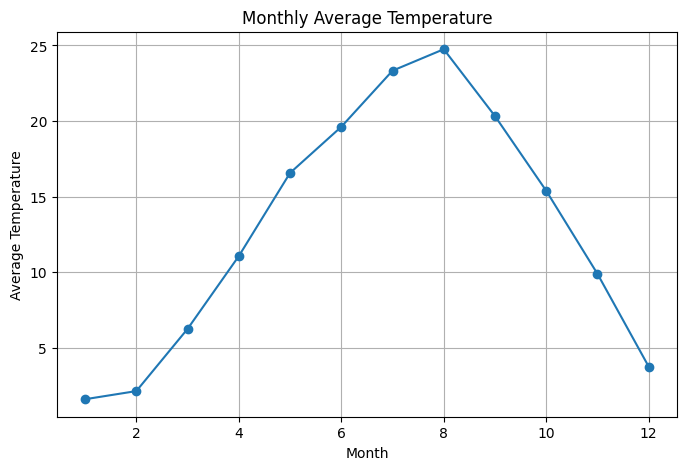


평균 기온이 가장 높은 달: 8


In [19]:
# -------------------------------
# 2. weather.csv
# -------------------------------
weather_path = '/content/drive/MyDrive/Machine Learning/weather.csv'
weather = pd.read_csv(weather_path, encoding='CP949')

print("\n각 열의 결손값 개수")
print(weather.isnull().sum())

date_col = '일시'
temp_col = '평균기온'
wind_col = '평균풍속'

print(f"\n{wind_col} 결손값이 있는 행")
print(weather[weather[wind_col].isnull()])

mean_wind = weather[wind_col].mean()
weather[wind_col] = weather[wind_col].fillna(mean_wind)

print(f"\n채운 뒤 {wind_col} 결손값 개수")
print(weather[wind_col].isnull().sum())

weather[date_col] = pd.to_datetime(weather[date_col])
weather['month'] = weather[date_col].dt.month

monthly_temp = weather.groupby('month')[temp_col].mean()

print("\n월별 평균 기온")
print(monthly_temp)

plt.figure(figsize=(8, 5))
plt.plot(monthly_temp.index, monthly_temp.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Average Temperature')
plt.title('Monthly Average Temperature')
plt.grid(True)
plt.show()

print("\n평균 기온이 가장 높은 달:", monthly_temp.idxmax())